<a href="https://colab.research.google.com/github/diemacedo12/lis4693-lis5693/blob/main/lab-7/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing packages

In [41]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

 Loading BBC news dataset

In [42]:
import requests
import io

url = "https://raw.githubusercontent.com/diemacedo12/lis4693-lis5693/refs/heads/main/lab-4/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text
df = pd.read_csv(io.StringIO(text), sep='\t')

print(df.head())

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


Creating a subset

In [43]:
df_subset = df[['filename', 'content']].copy()

Cleaning text and removing non-alphabet characters and converting to lowercase

In [44]:
df_subset['ObjectId'] = df_subset['filename'].str.replace('.txt', '').astype(int)

df_subset = df_subset.rename(columns={'content': 'Description'})

df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", " ")

df_subset['Description'] = df_subset['Description'].str.casefold()

print(df_subset.head(10))

  filename                                        Description  ObjectId
0  001.txt   quarterly profits at us media giant timewarne...         1
1  002.txt   the dollar has hit its highest level against ...         2
2  003.txt   the owners of embattled russian oil giant yuk...         3
3  004.txt   british airways has blamed high fuel prices f...         4
4  005.txt   shares in uk drinks and food firm allied dome...         5
5  006.txt   japan's economy teetered on the brink of a te...         6
6  007.txt   the us created fewer jobs than expected in ja...         7
7  008.txt   india, which attends the g7 meeting of seven ...         8
8  009.txt   ethiopia produced 14.27 million tonnes of cro...         9
9  010.txt   a us government claim accusing the country's ...        10


Using VADER to generate compound sentiment polarity scores



In [45]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = []

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description'])
    for key, value in scores.items():
        all_scores_list.append({
            'ObjectId': row['ObjectId'],
            'sentiment_type': key,
            'sentiment_score': value
        })

t_df_all_types = pd.DataFrame(all_scores_list)

t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    ObjectId sentiment_type  sentiment_score
3          1       compound           0.9950
7          2       compound           0.9347
11         3       compound          -0.8860
15         4       compound           0.9790
19         5       compound           0.6652
23         6       compound           0.6204
27         7       compound           0.9547
31         8       compound          -0.6795
35         9       compound          -0.2023
39        10       compound           0.2263


Merging sentiment scores back to the original dataset + creating unique ID







In [46]:
df['ObjectId'] = df['filename'].str.replace('.txt', '').astype(int)

t_df_final = t_df_cleaned.drop_duplicates(subset=['ObjectId'])

df_output = pd.merge(df, t_df_final, on='ObjectId', how='inner')
print(df_output.head(10))

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   
5  business  006.txt   Japan narrowly escapes recession   
6  business  007.txt   Jobs growth still slow in the US   
7  business  008.txt   India calls for fair trade rules   
8  business  009.txt  Ethiopia's crop production up 24%   
9  business  010.txt  Court rejects $280bn tobacco case   

                                             content  ObjectId sentiment_type  \
0   Quarterly profits at US media giant TimeWarne...         1       compound   
1   The dollar has hit its highest level against ...         2       compound   
2   The owners of embattled Russian oil giant Yuk...         3       compound   
3   British Airways has bl

Generating summary statistics of sentiment scores



In [47]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,2225.000000
mean,0.254684
std,0.817809
min,-0.998700
25%,-0.771700
50%,0.771700
75%,0.957100
max,0.999500


What is the 'text' field for your dataset?

The text field for my dataset is content.

Which common column did you choose to merge your original dataset with the sentiment scores?

I used the ObjectId column.


Briefly explain your sentiment polarity results using the describe method.

The mean sentiment score is positive (0.25). Many articles have strongly positive sentiment (median: 0.77), although some are negative. This makes sense for business news, which often covers profits, growth, and successful deals.

Visualizing sentiment scores using a bar plot


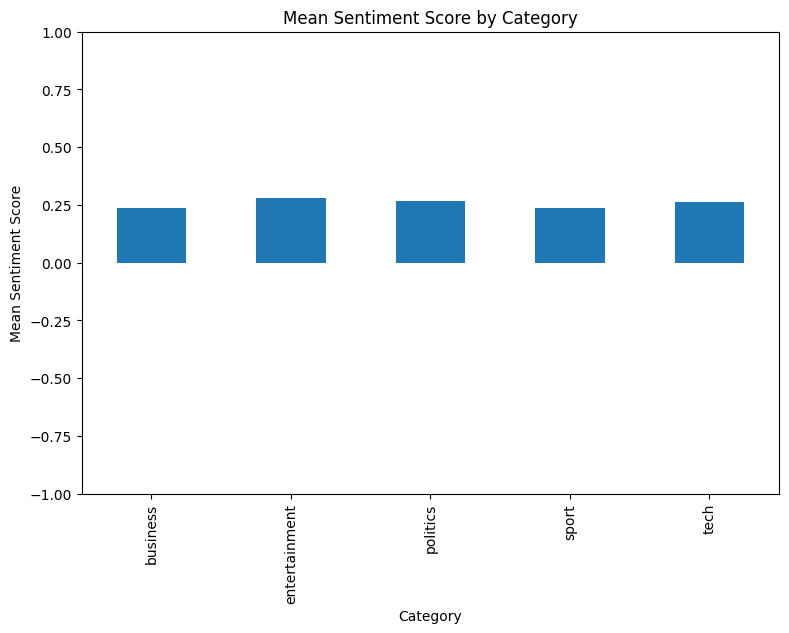

In [48]:
dfg = df_output.groupby(['category'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='Mean Sentiment Score by Category', ylabel='Mean Sentiment Score',
         xlabel='Category', figsize=(9, 6))

plt.ylim(-1, 1)
plt.show()

In [49]:
import altair as alt


dfg_category = df_output.groupby('category')['sentiment_score'].mean().reset_index()


chart_category = alt.Chart(dfg_category).mark_bar().encode(
    x=alt.X('category:N', title='News Category', sort='-y'),
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score', scale=alt.Scale(domain=[-1, 1])),
    color=alt.Color('category:N', legend=alt.Legend(title="Category")),
    tooltip=['category', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by BBC News Category',
    width=600,
    height=400
).interactive()

chart_category

alt.Chart(...)

The bar plot shows the mean sentiment score by category.  

The Altair chart also shows the mean sentiment score by category. Overall, the sentiment in BBC business news leans positive.

Reflection

What went well? What did not go well, or what challenges did you encounter?

Loading the data with sep='\t' and running the sentiment analysis went well. The main challenge was that the sentiment scores across categories were very close together, so the bar plot did not look right at first. Visualization was the hardest part. Rest of the assignment was a breeze.

In what ways could sentiment analysis be integrated into your current or future professional or research work?

Sentiment analysis can help check the tone of news articles or track how positive or negative the coverage is on different topics.